In [21]:
import os

import torch
from torchvision.utils import make_grid
from matplotlib import pyplot as plt

from sde_lib import (
    GaussianConditionalProbabilityPath,
    LinearConditionalProbabilityPath,
    IsotropicGaussian,
    MNISTSampler,
    LinearAlpha,
    LinearBeta,
    MNISTUNet,
    CFGTrainer,
    CFGVectorFieldODE,
    EulerSimulator,
)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [22]:
path = LinearConditionalProbabilityPath(p_data=MNISTSampler(), p_simple_shape=[1, 32, 32]).to(device)

# path = GaussianConditionalProbabilityPath(p_data=MNISTSampler(), p_simple_shape=[1, 32, 32], alpha=LinearAlpha(), beta=LinearBeta()).to(device)

unet = MNISTUNet(
    channels=[32, 64, 128],
    num_residual_layers=2,
    t_embed_dim=40,
    y_embed_dim=40,
).to(device)

trainer = CFGTrainer(path=path, model=unet, eta=0.1, device=device)
losses = trainer.train(num_epochs=5000, lr=1e-3, batch_size=256)

Training model with size: 4.715 MiB


Epoch 4999, loss: 140.77383422851562: : 5000it [38:01,  2.19it/s] 


In [23]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib_gaussian.pth")
checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib_linear.pth")
torch.save({
    'model_state_dict': unet.state_dict(),
    'optimizer_state_dict': trainer.get_optimizer(lr=1e-3).state_dict(),
    'losses': losses,
    'epoch': 5000,
    'model_config': {
        'channels': [32, 64, 128],
        'num_residual_layers': 2,
        't_embed_dim': 40,
        'y_embed_dim': 40
    }
}, checkpoint_path)
print(f"Model saved to: {checkpoint_path}")

Model saved to: checkpoints/mnist_cfg_unet_sde_lib_linear.pth


In [24]:
checkpoint_dir = "checkpoints"
# checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib_gaussian.pth")
checkpoint_path = os.path.join(checkpoint_dir, "mnist_cfg_unet_sde_lib_linear.pth")
loaded_checkpoint = torch.load(checkpoint_path, map_location=device)

unet = MNISTUNet(**loaded_checkpoint['model_config']).to(device)
unet.load_state_dict(loaded_checkpoint['model_state_dict'])
unet.eval()

print(f"Model loaded from: {checkpoint_path}")
print(f"Training epochs: {loaded_checkpoint['epoch']}")
print(f"Final loss: {loaded_checkpoint['losses'][-1]:.4f}")

Model loaded from: checkpoints/mnist_cfg_unet_sde_lib_linear.pth
Training epochs: 5000
Final loss: 140.7738


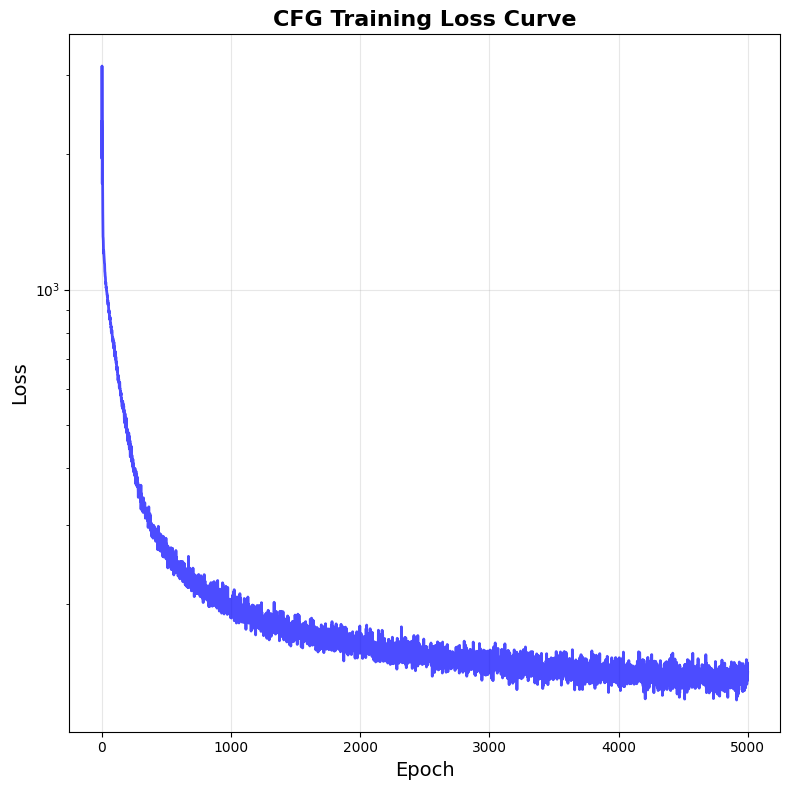

Initial loss: 2364.0552
Final loss: 140.7738
Loss reduction: 94.05%


In [25]:
# Plot training loss curve
plt.figure(figsize=(8, 8))
plt.plot(losses, linewidth=2, color='blue', alpha=0.7)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('CFG Training Loss Curve', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visualization
plt.tight_layout()
# plt.savefig("cfg_gaussian_training_loss_curve.png", dpi=300)
plt.savefig("cfg_linear_training_loss_curve.png", dpi=300)
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.2f}%")

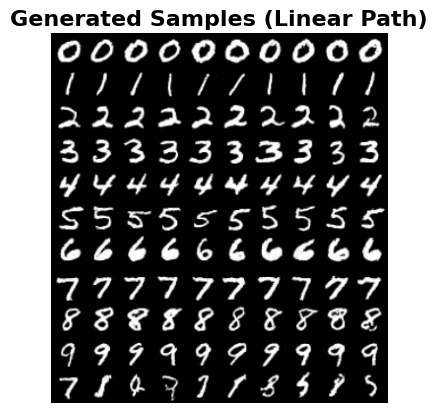

In [26]:
# Example sampling (after training):
ode = CFGVectorFieldODE(unet, guidance_scale=3.0)
simulator = EulerSimulator(ode)
y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(10).to(device)
x0, _ = path.p_simple.sample(y.shape[0])
ts = torch.linspace(0, 1, 100).view(1, -1, 1, 1, 1).expand(y.shape[0], -1, 1, 1, 1).to(device)
x1 = simulator.simulate(x0, ts, y=y)
grid = make_grid(x1, nrow=10, normalize=True, value_range=(-1, 1))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
# plt.title("Generated Samples (Gaussian Path)", fontsize=16, fontweight='bold')
# plt.savefig("cfg_gaussian_generated_samples.png", dpi=300)
plt.title("Generated Samples (Linear Path)", fontsize=16, fontweight='bold')
plt.savefig("cfg_linear_generated_samples.png", dpi=300)
plt.show()